<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 1.2</h1>

The aim of this exercise is to verify the **Central Limit Theorem (CLT)** by studying the behavior of the average

$$
S_N = \frac{1}{N}\sum_{i=1}^N x_i
$$

of $N$ independent and identically distributed random variables.

In particular, three different probability distributions are considered: the **uniform distribution**, corresponding to a standard dice, the **exponential distribution**, and the **Cauchy-Lorentz distribution**. For each distribution, $10^4$ independent realizations of $S_N$ are generated for different values of the number of random variables,

$$
N = 1, 2, 10, 100.
$$

The exponential distribution is defined as

$$
p(x) = \lambda e^{-\lambda x},
\qquad x \geq 0,
$$

while the Cauchy-Lorentz distribution is described by

$$
p(x) =
\frac{1}{\pi}
\frac{\Gamma}
{(x-\mu)^2+\Gamma^2}.
$$

In this exercise, the unfiorm distribution is considered $U(1,6)$, the exponential distribution is considered with $\lambda=1$, while the Cauchy-Lorentz distribution is considered with $\mu=0$ and $\Gamma=1$.

The two additional probability distributions are sampled using the **method of inversion of the cumulative distribution function**.

The resulting distributions of $S_N$ are then studied for increasing values of $N$. According to the Central Limit Theorem, the averages obtained from the uniform and exponential distributions are expected to converge towards a **Gaussian distribution** as $N$ increases. In contrast, the Cauchy-Lorentz distribution does not satisfy the conditions required by the Central Limit Theorem, and its stability under averaging leads to a Cauchy-Lorentz distribution also for increasing values of $N$.

The results obtained for the three cases are compared in order to investigate their different convergence properties and the role played by the **basin of attraction** of the underlying probability distributions.


### Central Limit Theorem

The Central Limit Theorem states that, under suitable conditions, the average of a sufficiently large number of independent and identically distributed random variables approaches a Gaussian distribution, regardless of the specific form of the original probability distribution.

Consider a set of $N$ independent and identically distributed random variables $x_i$, each with finite mean $\mu$ and finite variance $\sigma^2$. The corresponding sample mean is

$$
\bar{x}_N =
\frac{1}{N}
\sum_{i=1}^{N} x_i.
$$

As $N$ increases, the distribution of the sample mean approaches a Gaussian distribution. Its mean and variance are

$$
\mathbb{E}[\bar{x}_N] = \mu
$$

and

$$
\mathrm{Var}(\bar{x}_N) = \frac{\sigma^2}{N}.
$$

Therefore, the mean remains unchanged, while the variance decreases as $1/N$.

The requirement of finite mean and variance is crucial. Probability distributions can be classified according to their **basin of attraction**, which determines the stable distribution towards which properly normalized sums of independent random variables converge.

The uniform and exponential distributions have finite mean and variance and belong to the basin of attraction of the Gaussian distribution. Therefore, as the number of variables used to construct each realization increases, we expect the distributions of their averages to become increasingly similar to a Gaussian distribution.

The Cauchy-Lorentz distribution behaves differently. Its mean and variance do not exist because of its heavy tails. Consequently, the standard form of the Central Limit Theorem does not apply. Instead, the Cauchy distribution is a **stable distribution**: a sum of independent Cauchy-distributed random variables is itself Cauchy distributed. In particular, if

$$
x_i \sim C(\mu,\Gamma),
$$

then

$$
\sum_{i=1}^{N} x_i \sim C(N\mu,N\Gamma),
$$

and therefore

$$
\frac{1}{N}\sum_{i=1}^{N}x_i \sim C(\mu,\Gamma).
$$

Thus, the distribution of the sample mean is independent of $N$. Therefore, in this exercise we expect the uniform and exponential distributions to approach a Gaussian shape as the number of variables increases, whereas the Cauchy-Lorentz distribution is expected to retain its characteristic Cauchy-Lorentz shape.


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.stats import norm
from scipy.stats import cauchy

In [2]:
u1 = np.loadtxt('ave_prog_Uniform Distribution_1.txt')
u2 = np.loadtxt('ave_prog_Uniform Distribution_2.txt')
u3 = np.loadtxt('ave_prog_Uniform Distribution_10.txt')
u4 = np.loadtxt('ave_prog_Uniform Distribution_100.txt')

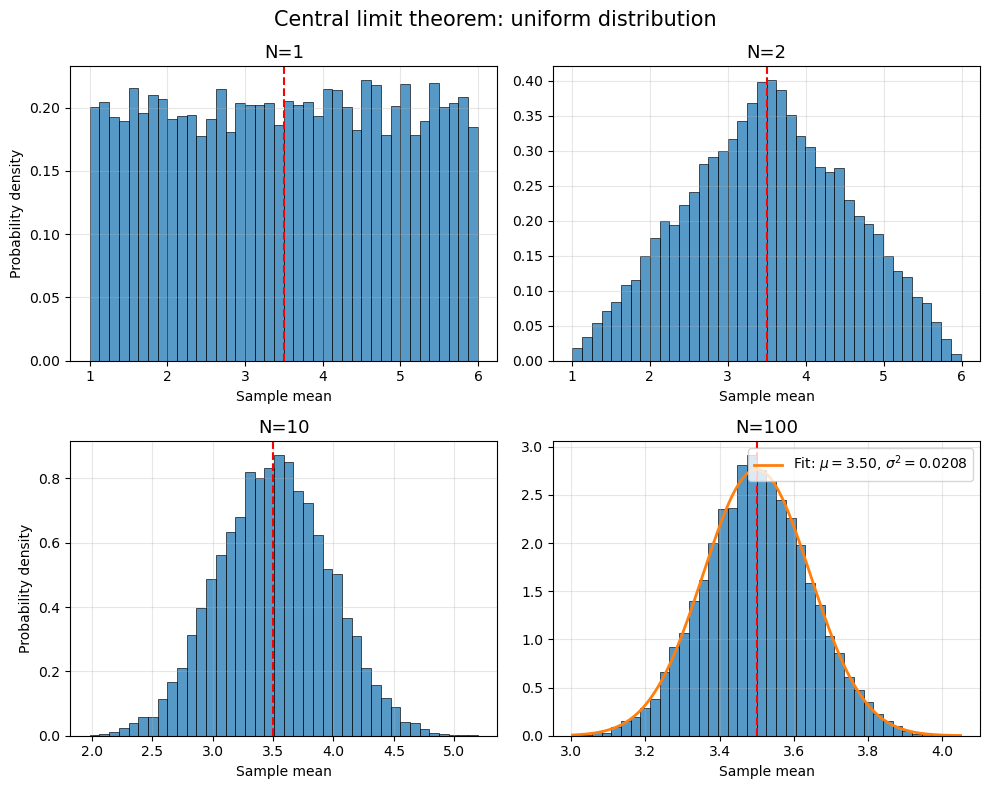

In [12]:
fig, axs1 = plt.subplots(2, 2, figsize=(10, 8))
axs1 = axs1.flatten()

datasets = [u1, u2, u3, u4]
titles = [
    "N=1",
    "N=2",
    "N=10",
    "N=100",
]

for ax, data, title in zip(axs1, datasets, titles):

    ax.hist(
        data,
        bins=40,
        density=True,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.75
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sample mean")
    ax.grid(alpha=0.3)

    ax.axvline(
        3.5,
        color="red",
        linestyle="--",
        linewidth=1.5
    )

N = 100
a = 1
b = 6
mu = (b + a) / 2
sigma = (b - a) / np.sqrt(12 * N)
variance = sigma**2

x = np.linspace(min(u4), max(u4), 500)

axs1[3].plot(
    x,
    norm.pdf(x, mu, sigma),
    linewidth=2,
    label=fr"Fit: $\mu={mu:.2f}$, $\sigma^2={variance:.4f}$"
)

axs1[3].legend(loc="upper right")

axs1[0].set_ylabel("Probability density")
axs1[2].set_ylabel("Probability density")

plt.suptitle(
    "Central limit theorem: uniform distribution",
    fontsize=15
)

plt.tight_layout()
plt.show()

**Figure 1.** Histograms of the sample mean $S_N$ obtained from $10^4$ realizations of a uniform distribution corresponding to a standard dice, for increasing values of $N$. As the number of variables increases, the distribution progressively approaches a Gaussian distribution, as expected from the Central Limit Theorem.

In [4]:
e1 = np.loadtxt('ave_prog_Exponential Distribution_1.txt')
e2 = np.loadtxt('ave_prog_Exponential Distribution_2.txt')
e3 = np.loadtxt('ave_prog_Exponential Distribution_10.txt')
e4 = np.loadtxt('ave_prog_Exponential Distribution_100.txt')

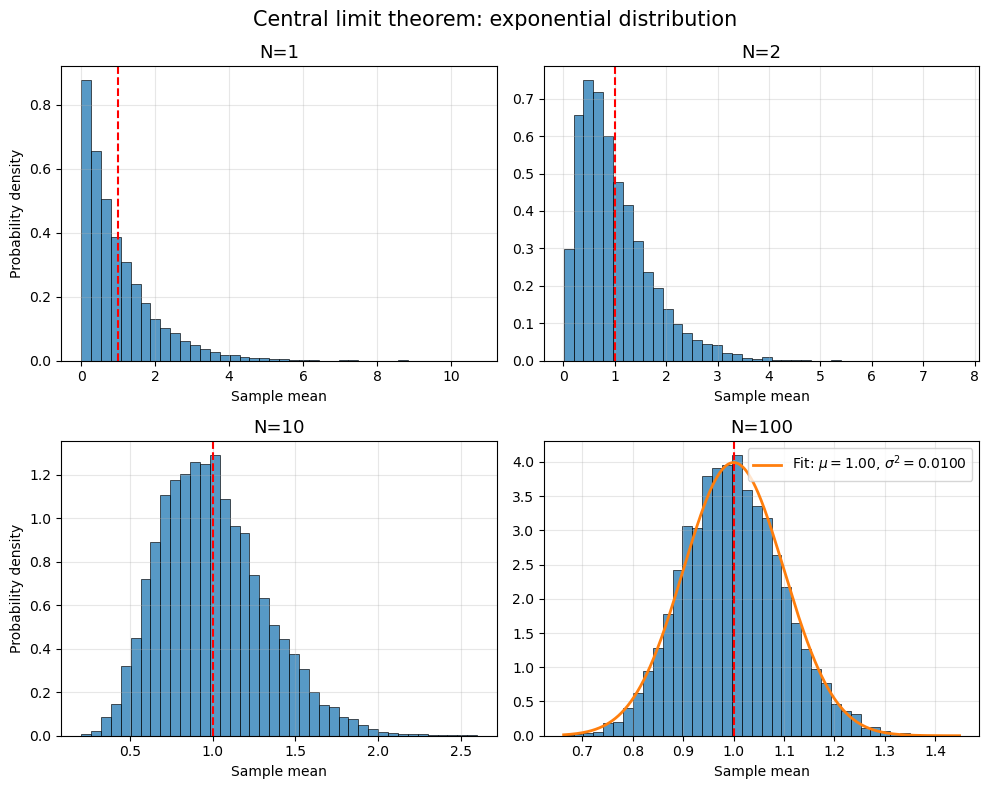

In [13]:
fig, axs2 = plt.subplots(2, 2, figsize=(10, 8))
axs2 = axs2.flatten()

datasets = [e1, e2, e3, e4]
titles = [
    "N=1",
    "N=2",
    "N=10",
    "N=100",
]

for ax, data, title in zip(axs2, datasets, titles):

    ax.hist(
        data,
        bins=40,
        density=True,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.75
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sample mean")
    ax.grid(alpha=0.3)

    ax.axvline(
        1,
        color="red",
        linestyle="--",
        linewidth=1.5,
    )

N = 100
lambda_exp = 1
mu = 1 / lambda_exp
sigma = 1 / (lambda_exp * np.sqrt(N))
variance = sigma**2

x = np.linspace(min(e4), max(e4), 500)

axs2[3].plot(
    x,
    norm.pdf(x, mu, sigma),
    linewidth=2,
    label=fr"Fit: $\mu={mu:.2f}$, $\sigma^2={variance:.4f}$"
)

axs2[3].legend(loc="upper right")

axs2[0].set_ylabel("Probability density")
axs2[2].set_ylabel("Probability density")

plt.suptitle(
    "Central limit theorem: exponential distribution",
    fontsize=15
)

plt.tight_layout()
plt.show()

**Figure 2.** Histograms of the sample mean $S_N$ obtained from $10^4$ realizations of an exponential distribution with $\lambda=1$, for increasing values of $N$. As $N$ increases, the distribution progressively approaches a Gaussian distribution, in agreement with the Central Limit Theorem.

In [6]:
c1 = np.loadtxt('ave_prog_Cauchy Distribution_1.txt')
c2 = np.loadtxt('ave_prog_Cauchy Distribution_2.txt')
c3 = np.loadtxt('ave_prog_Cauchy Distribution_10.txt')
c4 = np.loadtxt('ave_prog_Cauchy Distribution_100.txt')

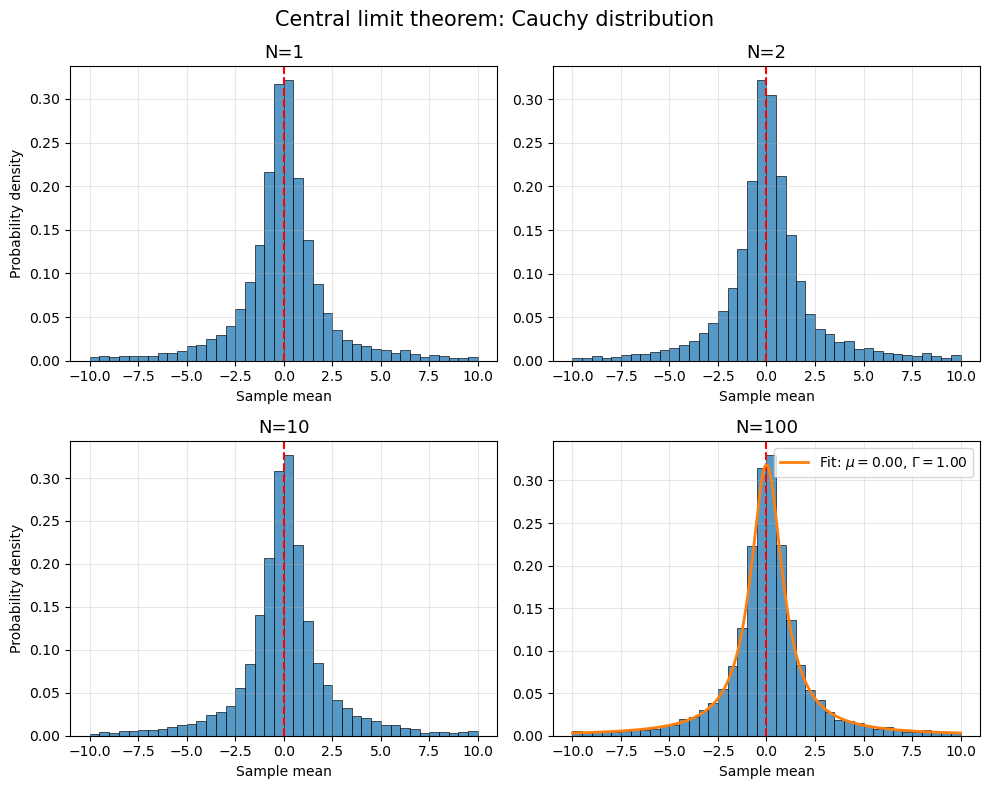

In [17]:
fig, axs3 = plt.subplots(2, 2, figsize=(10, 8))
axs3 = axs3.flatten()

datasets = [c1, c2, c3, c4]
titles = [
    "N=1",
    "N=2",
    "N=10",
    "N=100",
]

for ax, data, title in zip(axs3, datasets, titles):

    ax.hist(
        data,
        bins=40,
        density=True,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.75,
        range=(-10, 10)
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sample mean")
    ax.grid(alpha=0.3)

    ax.axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1.5
    )

mu = 0
gamma = 1

x = np.linspace(-10, 10, 500)

axs3[3].plot(
    x,
    cauchy.pdf(x, mu, gamma),
    linewidth=2,
    label=fr"Fit: $\mu={mu:.2f}$, $\Gamma={gamma:.2f}$"
)

axs3[3].legend(loc="upper right")

axs3[0].set_ylabel("Probability density")
axs3[2].set_ylabel("Probability density")

plt.suptitle(
    "Central limit theorem: Cauchy distribution",
    fontsize=15
)

plt.tight_layout()
plt.show()

**Figure 3.** Histograms of the sample mean $S_N$ obtained from $10^4$ realizations of a Cauchy-Lorentz distribution with $\mu=0$ and $\Gamma=1$, for increasing values of $N$. Unlike the uniform and exponential cases, the distribution retains its Cauchy-Lorentz shape as $N$ increases, reflecting the stability of the Cauchy-Lorentz distribution. 